Binary MLP classifier for MNIST even/odd classification, trained maximizing a posterior.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


train_df = pd.read_csv("mnist_train.csv", header=None)
test_df = pd.read_csv("mnist_test.csv", header=None)

# x - array of pixel intensities, y - array of labels

X_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values



# Normalize intesities 

X_train = X_train / 255.0
X_test = X_test / 255.0



# Convert labels to parity 

y_train_binary = y_train % 2
y_test_binary = y_test % 2



# Number of hidden neurons
H = 64

np.random.seed(0)

# Input -> hidden
# Create a matrix of weights for the input to hidden layer, initialized with small random values
W1 = np.random.randn(784, H) * 0.01
# Create a vector of biases for the hidden layer, initialized with zeros
b1 = np.zeros((1, H)) 


# Hidden -> output
# Create a matrix of weights for the hidden to output layer, initialized with small random values
W2 = np.random.randn(H, 1) * 0.01
# Create a scalar bias for the output layer, initialized with zero
b2 = 0.0 



def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# reshape labels to column vectors
y_train_binary = y_train_binary.reshape(-1, 1)
y_test_binary = y_test_binary.reshape(-1, 1)



# Forward pass function to compute activations for both layers

def forward(X, W1, b1, W2, b2):
    # Compute activations for the hidden layer
    Z1 = X @ W1 + b1 
    A1 = sigmoid(Z1)

    # Compute activations for the output layer
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    return Z1, A1, Z2, A2



# Binary cross-entropy loss function to compute the loss between true labels and predicted probabilities

def binary_cross_entropy(y, y_hat):
    eps = 1e-10
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))



# Training loop: estimate errors, do backpropagation, update weights.

learning_rate = 0.5
loops = 3000
lambda_ = 3e-5

m = X_train.shape[0]

losses = []

for loop_number in range(loops):
    # forward pass
    Z1, A1, Z2, y_hat = forward(X_train, W1, b1, W2, b2)

    # BCE loss
    bce_loss = binary_cross_entropy(y_train_binary, y_hat)

    # MAP / L2 regularisation loss
    l2_loss = lambda_ * (np.sum(W1 ** 2) + np.sum(W2 ** 2))

    loss = bce_loss + l2_loss
    losses.append(loss)

    # backpropagation
    dZ2 = y_hat - y_train_binary
    dW2 = A1.T @ dZ2 / m
    db2 = np.mean(dZ2)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * A1 * (1 - A1)
    dW1 = X_train.T @ dZ1 / m
    db1 = np.mean(dZ1, axis=0, keepdims=True)

    # add regularization gradients
    dW1 += 2 * lambda_ * W1
    dW2 += 2 * lambda_ * W2

    # update weights
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if loop_number % 100 == 0:
        print(f"Epoch {loop_number}, Loss: {loss:.4f}")

    losses.append(loss)

Epoch 0, Loss: 0.6934
Epoch 100, Loss: 0.3308
Epoch 200, Loss: 0.2963
Epoch 300, Loss: 0.2842
Epoch 400, Loss: 0.2754
Epoch 500, Loss: 0.2645
Epoch 600, Loss: 0.2483
Epoch 700, Loss: 0.2281
Epoch 800, Loss: 0.2069
Epoch 900, Loss: 0.1880
Epoch 1000, Loss: 0.1724
Epoch 1100, Loss: 0.1603
Epoch 1200, Loss: 0.1508
Epoch 1300, Loss: 0.1432
Epoch 1400, Loss: 0.1369
Epoch 1500, Loss: 0.1315
Epoch 1600, Loss: 0.1267
Epoch 1700, Loss: 0.1223
Epoch 1800, Loss: 0.1184
Epoch 1900, Loss: 0.1148
Epoch 2000, Loss: 0.1116
Epoch 2100, Loss: 0.1086
Epoch 2200, Loss: 0.1058
Epoch 2300, Loss: 0.1033
Epoch 2400, Loss: 0.1010
Epoch 2500, Loss: 0.0989
Epoch 2600, Loss: 0.0969
Epoch 2700, Loss: 0.0950
Epoch 2800, Loss: 0.0933
Epoch 2900, Loss: 0.0916


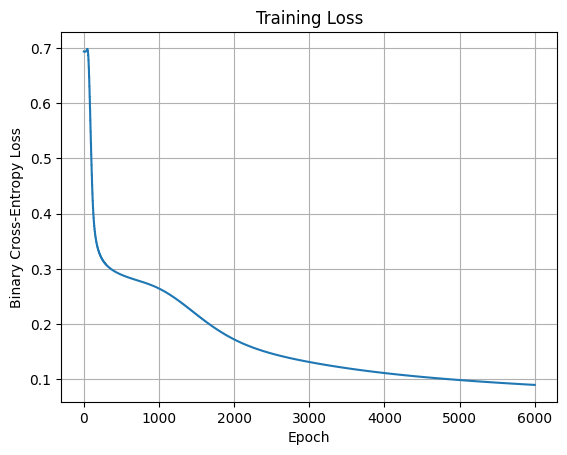

In [26]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

In [27]:
# Accuracy test

_, _, _, y_pred_train = forward(X_train, W1, b1, W2, b2)
_, _, _, y_pred_test = forward(X_test, W1, b1, W2, b2)

train_acc = np.mean((y_pred_train >= 0.5) == y_train_binary)
test_acc = np.mean((y_pred_test >= 0.5) == y_test_binary)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

print(np.linalg.norm(W1), np.linalg.norm(W2))

Train accuracy: 0.9727
Test accuracy: 0.9687
10.564251538174183 10.567828371569757
